# Coursework Template

## Setup

**Dependencies and imports**

This can take a minute...

In [1]:
# !pip install swig
# !pip install rldurham

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""  # disable CUDA (better on Colab/NCC: choose an environment without GPU)
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import rldurham as rld

In [3]:
device = torch.device("cpu")

**Reinforcement learning agent**

Replace this with your own agent. Also see the SAC implementationi below for a starting point.

In [4]:
"""
https://github.com/Rafael1s/Deep-Reinforcement-Learning-Algorithms/tree/master/BipedalWalker-TwinDelayed-DDPG%20(TD3)
"""
# Actor Neural Network
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, max_action):
        super(Actor, self).__init__()

        self.l1 = nn.Linear(state_dim, 400)
        self.l2 = nn.Linear(400, 300)
        self.l3 = nn.Linear(300, action_dim)

        self.max_action = max_action



    def forward(self, x):
        x = F.relu(self.l1(x))
        x = F.relu(self.l2(x))
        x = self.max_action * torch.tanh(self.l3(x)) 
        return x
    
# Q1-Q2-Critic Neural Network    
class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Critic, self).__init__()

        # Q1 architecture
        self.l1 = nn.Linear(state_dim + action_dim, 400)
        self.l2 = nn.Linear(400, 300)
        self.l3 = nn.Linear(300, 1)

        # Q2 architecture
        self.l4 = nn.Linear(state_dim + action_dim, 400)
        self.l5 = nn.Linear(400, 300)
        self.l6 = nn.Linear(300, 1)


    def forward(self, x, u):
        xu = torch.cat([x, u], 1)

        x1 = F.relu(self.l1(xu))
        x1 = F.relu(self.l2(x1))
        x1 = self.l3(x1)

        x2 = F.relu(self.l4(xu))
        x2 = F.relu(self.l5(x2))
        x2 = self.l6(x2)
        return x1, x2



    def Q1(self, x, u):
        xu = torch.cat([x, u], 1)

        x1 = F.relu(self.l1(xu))
        x1 = F.relu(self.l2(x1))
        x1 = self.l3(x1)
        return x1 
    

In [5]:
# Expects tuples of (state, next_state, action, reward, done)
class ReplayBuffer(object):
    def __init__(self, max_size=1e6):
        self.storage = []
        self.max_size = max_size
        self.ptr = 0

    def add(self, data):
        if len(self.storage) == self.max_size:
            self.storage[int(self.ptr)] = data
            self.ptr = (self.ptr + 1) % self.max_size
        else:
            self.storage.append(data)

    def sample(self, batch_size):
        ind = np.random.randint(0, len(self.storage), size=batch_size)
        x, y, u, r, d = [], [], [], [], []

        for i in ind: 
            X, Y, U, R, D = self.storage[i]
            x.append(np.array(X))
            y.append(np.array(Y))
            u.append(np.array(U))
            r.append(np.array(R))
            d.append(np.array(D))

        return np.array(x), np.array(y), np.array(u), np.array(r).reshape(-1, 1), np.array(d).reshape(-1, 1)   
    

In [6]:
class Agent(torch.nn.Module):
    def __init__(self, env):
        super(Agent, self).__init__()
        self.discrete_act, self.discrete_obs, self.act_dim, self.obs_dim = rld.env_info(env)
        self.max_action = env.action_space.high[0]
        self.replay_buf = ReplayBuffer() 
        
        self.actor = Actor(self.obs_dim, self.act_dim, self.max_action).to(device)
        self.actor_target = Actor(self.obs_dim, self.act_dim, self.max_action).to(device)
        self.actor_target.load_state_dict(self.actor.state_dict())
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters())

        self.critic = Critic(self.obs_dim, self.act_dim).to(device)
        self.critic_target = Critic(self.obs_dim, self.act_dim).to(device)
        self.critic_target.load_state_dict(self.critic.state_dict())
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters())

    def sample_action(self, s):
        # return torch.rand(self.act_dim) * 2 - 1 # unifrom random in [-1, 1]
        state = torch.FloatTensor(s.reshape(1, -1)).to(device)
        return self.actor(state).cpu().data.numpy().flatten()
    
    def put_data(self, state, action, observation, reward, done):
        self.replay_buf.add((state, observation, action, reward, done))

    def train(self, iterations, batch_size=100, discount=0.99, \
              tau=0.005, policy_noise=0.2, noise_clip=0.5, policy_freq=2):
        
        replay_buffer = self.replay_buf
        for it in range(iterations):
            # Sample replay buffer 
            x, y, u, r, d = replay_buffer.sample(batch_size)
            state = torch.FloatTensor(x).to(device)
            action = torch.FloatTensor(u).to(device)
            next_state = torch.FloatTensor(y).to(device)
            done = torch.FloatTensor(1 - d).to(device)
            reward = torch.FloatTensor(r).to(device)

            # Select action according to policy and add clipped noise 
            noise = torch.FloatTensor(u).data.normal_(0, policy_noise).to(device)
            noise = noise.clamp(-noise_clip, noise_clip)
            next_action = (self.actor_target(next_state) + noise).clamp(-self.max_action, self.max_action)

            # Compute the target Q value
            target_Q1, target_Q2 = self.critic_target(next_state, next_action)
            target_Q = torch.min(target_Q1, target_Q2)
            target_Q = reward + (done * discount * target_Q).detach()

            # Get current Q estimates
            current_Q1, current_Q2 = self.critic(state, action)

            # Compute critic loss
            critic_loss = F.mse_loss(current_Q1, target_Q) + F.mse_loss(current_Q2, target_Q) 

            # Optimize the critic
            self.critic_optimizer.zero_grad()
            critic_loss.backward()
            self.critic_optimizer.step()

            # Delayed policy updates
            if it % policy_freq == 0:

                # Compute actor loss
                actor_loss = -self.critic.Q1(state, self.actor(state)).mean()
                # Optimize the actor 
                self.actor_optimizer.zero_grad()
                actor_loss.backward()
                self.actor_optimizer.step()

                # Update the frozen target models
                for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
                    target_param.data.copy_(tau * param.data + (1 - tau) * target_param.data)

                for param, target_param in zip(self.actor.parameters(), self.actor_target.parameters()):
                    target_param.data.copy_(tau * param.data + (1 - tau) * target_param.data)

## Training

**Prepare the environment and wrap it to capture statistics, logs, and videos**

The device is: cpu (as recommended)
actions are continuous with 4 dimensions/#actions
observations are continuous with 24 dimensions/#observations
maximum timesteps is: 2000


C:\Users\Canic\PycharmProjects\reinforcementLearning\.venv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at C:\Users\Canic\PycharmProjects\reinforcementLearning\courseWork\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


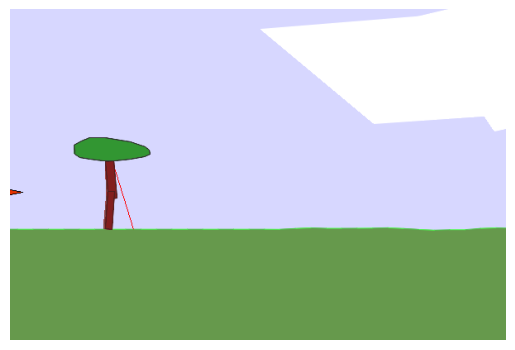

In [7]:
env = rld.make("rldurham/Walker", render_mode="rgb_array")
# env = rld.make("rldurham/Walker", render_mode="rgb_array", hardcore=True) # only attempt this when your agent has solved the non-hardcore version

# get statistics, logs, and videos
env = rld.Recorder(
    env,
    smoothing=10,                       # track rolling averages (useful for plotting)
    video=True,                         # enable recording videos
    video_folder="videos",              # folder for videos
    video_prefix="mwvy59-agent-video",  # prefix for videos (replace xxxx00 with your username)
    logs=True,                          # keep logs
)

# training on CPU recommended
rld.check_device()

# environment info
rld.env_info(env, print_out=True)

# render start image (reset just to render image)
env.reset(seed=42)
rld.render(env)

**Collect episodes and train the agent**

In [10]:
# in the submission please use seed_everything with seed 42 for verification
seed, observation, info = rld.seed_everything(42, env)

# initialise agent
agent = Agent(env)
max_episodes = 2000

# track statistics for plotting
tracker = rld.InfoTracker()

# switch video recording off (only switch on every x episodes as this is slow)
env.video = False

start_timestep=1e3
std_noise=0.02
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0] 
max_action = float(env.action_space.high[0])
# threshold = env.spec.reward_threshold
current_eps = 0

# training procedure
for episode in range(max_episodes):
    
    timestep = 0
    # recording statistics and video can be switched on and off (video recording is slow!)
    env.info = True                 # usually tracking every episode is fine
    env.video = episode % 100 == 0  # record videos every 100 episodes (set BEFORE calling reset!)

    # reset for new episode
    state, info = env.reset()
    low = env.action_space.low
    high = env.action_space.high

    # run episode
    done = False
    while not done:
        
        # Select action randomly or according to policy
        if current_eps < start_timestep:
            action = env.action_space.sample()
        else:
            action = agent.sample_action(np.array(state))
            if std_noise != 0: 
                shift_action = np.random.normal(0, std_noise, size=action_dim)
                action = (action + shift_action).clip(low, high)

        # take action in the environment
        observation, reward, terminated, truncated, info = env.step(action)
        
        # check whether done
        done = terminated or truncated
        
        # remember
        agent.put_data(state, action, observation, reward, done)
        # update state
        state = observation
        
        timestep += 1
        current_eps += 1
        
    # train the agent after each episode
    agent.train(timestep)
            
    # track and plot statistics
    tracker.track(info)
    if (episode + 1) % 10 == 0:
        tracker.plot(r_mean_=True, r_std_=True, r_sum=dict(linestyle=':', marker='x'))
    print("episode:{}, \tReward:{}".format(episode, int(reward)))
# don't forget to close environment (e.g. triggers last video save)
env.close()

# write log file (for coursework)
env.write_log(folder="logs", file="mwvy59-agent-log.txt")  # replace xxxx00 with your username

Seed set to 42


episode:0, 	Reward:-100
episode:1, 	Reward:0
episode:2, 	Reward:-100
episode:3, 	Reward:0


KeyboardInterrupt: 